# Quickstart: GHZ and Smoke Suite with Cirq

## Problem

Run a small, reproducible quantum benchmark workflow using only the public package API and the free local Cirq simulator.

## Quantum Advantage

None is claimed here. GHZ and the smoke suite are educational correctness and reporting examples, not demonstrations of practical quantum speedup.

## SDK Advantage

Cirq is useful for this first run because it is local, credential-free, easy to install from PyPI, and supports depolarizing-noise injection in this package.

## Variables

- `n_qubits`: number of qubits in the GHZ circuit.
- `shots`: measurement samples per backend run.
- `repeats`: repeated executions used to estimate local runtime variability.
- `backend`: package backend name, here `cirq`.
- `results`: standardized dictionaries returned by `run_benchmark`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from quantum_backend_bench.benchmarks.bernstein_vazirani import build_benchmark as build_bv
from quantum_backend_bench.benchmarks.ghz import build_benchmark as build_ghz
from quantum_backend_bench.benchmarks.grover import build_benchmark as build_grover
from quantum_backend_bench.core.runner import run_benchmark
from quantum_backend_bench.utils.formatting import format_results_table
from quantum_backend_bench.utils.io import save_csv, save_json

ARTIFACT_DIR = Path("../artifacts/notebooks")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

backend = "cirq"
n_qubits = 3
shots = 128
repeats = 1

## Run One GHZ Benchmark

A GHZ circuit prepares probability mass mostly on `|000>` and `|111>` for three qubits. The package returns counts, normalized distributions, structural metrics, runtime, and metadata in one standardized result record.


In [2]:
ghz = build_ghz(n_qubits=n_qubits)
ghz_results = run_benchmark(ghz, [backend], shots=shots, repeats=repeats)

print(format_results_table(ghz_results))

row = ghz_results[0]
summary = pd.DataFrame(
    [
        {
            "case": row["metadata"]["case_label"],
            "backend": row["backend"],
            "shots": row["shots"],
            "depth": row["metrics"]["depth"],
            "gates": row["metrics"]["gate_count"],
            "two_qubit_gates": row["metrics"]["two_qubit_gate_count"],
            "runtime_seconds": round(row["metrics"]["runtime_seconds"], 6),
            "tvd": round(row["metrics"]["total_variation_distance"], 6),
        }
    ]
)
summary

case    | backend | runtime_seconds | runtime_stddev | depth | gate_count | two_qubit_gate_count | success_prob
--------+---------+-----------------+----------------+-------+------------+----------------------+-------------
ghz n=3 | cirq    | 0.003383        | 0.000000       | 4     | 3          | 2                    | None        


,case,backend,shots,depth,gates,two_qubit_gates,runtime_seconds,tvd
0,ghz n=3,cirq,128,4,3,2,0.003383,0.0


## Plot the Measured Distribution

For an ideal three-qubit GHZ state, the dominant bitstrings are `|000>` and `|111>`. Shot noise can move the exact probabilities slightly around 0.5.


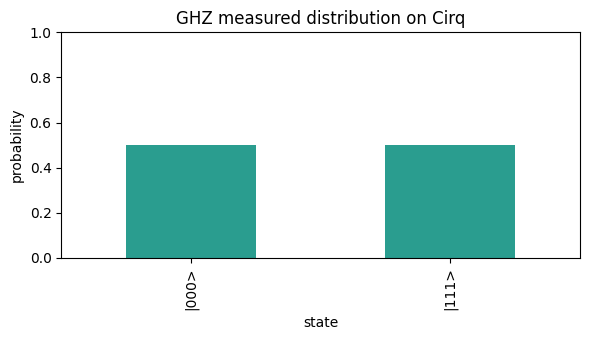

In [3]:
distribution = row["metrics"]["measurement_distribution"]


def ket(state):
    return f"|{state}>"


plot_data = pd.Series(distribution).sort_index(key=lambda index: [int(state, 2) for state in index])
plot_data.index = [ket(state) for state in plot_data.index]

fig, ax = plt.subplots(figsize=(6, 3.5))
plot_data.plot(kind="bar", ax=ax, color="#2a9d8f")
ax.set_title("GHZ measured distribution on Cirq")
ax.set_xlabel("state")
ax.set_ylabel("probability")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Run a Tiny Smoke Suite

This is a package-client version of the CLI smoke workflow: GHZ, Bernstein-Vazirani, and Grover, all through the same local backend.


In [4]:
suite_cases = [
    build_ghz(n_qubits=3),
    build_bv(n_qubits=4, secret_string="101"),
    build_grover(n_qubits=2, marked_state="11", iterations=2),
]

suite_results = []
for benchmark in suite_cases:
    suite_results.extend(run_benchmark(benchmark, [backend], shots=shots, repeats=repeats))

print(format_results_table(suite_results))

suite_table = pd.DataFrame(
    [
        {
            "case": result["metadata"]["case_label"],
            "backend": result["backend"],
            "depth": result["metrics"]["depth"],
            "gates": result["metrics"]["gate_count"],
            "success_probability": result["metrics"]["success_probability"],
            "tvd": result["metrics"]["total_variation_distance"],
            "runtime_seconds": result["metrics"]["runtime_seconds"],
        }
        for result in suite_results
    ]
)
suite_table["runtime_seconds"] = suite_table["runtime_seconds"].round(6)
suite_table["success_probability"] = suite_table["success_probability"].map(
    lambda value: None if value is None else round(value, 6)
)
suite_table["tvd"] = suite_table["tvd"].map(
    lambda value: None if value is None else round(value, 6)
)
suite_table

case                       | backend | runtime_seconds | runtime_stddev | depth | gate_count | two_qubit_gate_count | success_prob
---------------------------+---------+-----------------+----------------+-------+------------+----------------------+-------------
ghz n=3                    | cirq    | 0.002613        | 0.000000       | 4     | 3          | 2                    | None        
bernstein_vazirani s=|101> | cirq    | 0.006932        | 0.000000       | 6     | 10         | 2                    | 1.000000    
grover target=|11>         | cirq    | 0.009987        | 0.000000       | 14    | 22         | 4                    | 0.250000    


,case,backend,depth,gates,success_probability,tvd,runtime_seconds
0,ghz n=3,cirq,4,3,NaN,0.039062,0.002613
1,bernstein_vazirani s=|101>,cirq,6,10,1.00,0.000000,0.006932
2,grover target=|11>,cirq,14,22,0.25,NaN,0.009987


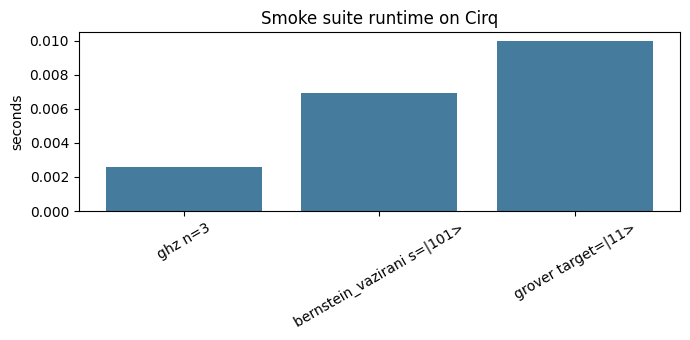

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(suite_table["case"], suite_table["runtime_seconds"], color="#457b9d")
ax.set_title("Smoke suite runtime on Cirq")
ax.set_ylabel("seconds")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Save Reproducible Artifacts

The JSON output keeps the full schema and metadata. CSV is convenient for quick inspection in spreadsheet tools.


In [6]:
json_path = save_json(suite_results, ARTIFACT_DIR / "quickstart_cirq_smoke.json")
csv_path = save_csv(suite_results, ARTIFACT_DIR / "quickstart_cirq_smoke.csv")
print(f"Saved JSON: {json_path}")
print(f"Saved CSV: {csv_path}")

Saved JSON: ../artifacts/notebooks/quickstart_cirq_smoke.json
Saved CSV: ../artifacts/notebooks/quickstart_cirq_smoke.csv


## Verification

These checks are intentionally simple and visible: total counts match requested shots, GHZ only produced the expected support states in ket notation, and Bernstein-Vazirani recovered the secret string with probability 1 in this run.


In [7]:
ghz_counts = ghz_results[0]["counts"]
bv_result = next(result for result in suite_results if result["benchmark"] == "bernstein_vazirani")

verification = pd.DataFrame(
    [
        {
            "check": "GHZ total counts equals shots",
            "value": sum(ghz_counts.values()),
            "expected": shots,
            "passed": sum(ghz_counts.values()) == shots,
        },
        {
            "check": "GHZ support is only |000>/|111>",
            "value": ", ".join(ket(state) for state in sorted(ghz_counts)),
            "expected": "|000>, |111>",
            "passed": set(ghz_counts).issubset({"000", "111"}),
        },
        {
            "check": "Bernstein-Vazirani success probability",
            "value": round(bv_result["metrics"]["success_probability"], 6),
            "expected": 1.0,
            "passed": bv_result["metrics"]["success_probability"] == 1.0,
        },
    ]
)
verification

,check,value,expected,passed
0,GHZ total counts equals shots,128,128,True
1,GHZ support is only |000>/|111>,"|000>, |111>","|000>, |111>",True
2,Bernstein-Vazirani success probability,1.0,1.0,True
